Answers for Week 7

* Name: Noah Demmenie
* Username: ndemmenie
* Student s-number: S6294588
* Group (AS1, etc.): AS3

**Question 7.1 : Linear algebra exercises**

In [11]:
import numpy as np
from numpy import linalg as la

A = np.array([1,2,3, 0,-4,1, 0,3,-1]).reshape(3,3)

print(f"det(A) = {la.det(A)}")

b = np.array([2,2,-1])
X = la.solve(A, b)
x, y, z = X 

print(f"\nSolution x, y, z = {x}, {y}, {z}")

print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")

Lambda, v = la.eig(A)
print(f"\nLambda = {Lambda}")

det(A) = 1.0

Solution x, y, z = 10.0, -1.0, -2.0

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]

Lambda = [ 1.         -4.79128785 -0.20871215]


**Question 7.3 : Applying a rotation matrix**

In [8]:
import numpy as np
from numpy import linalg as la

def Ey(beta):
    return np.array([np.cos(beta),0,-np.sin(beta), 0,1,0, np.sin(beta),0,np.cos(beta)]).reshape(3,3)
def Ez(gamma): 
    return np.array([np.cos(gamma),np.sin(gamma),0, -np.sin(gamma),np.cos(gamma),0, 0,0,1]).reshape(3,3)

gamma1 = np.radians(180-123)
beta = np.radians(90-27.4)
gamma2 = np.radians(192.25)

E = Ez(gamma1) @ Ey(beta) @ Ez(gamma2)
print(E)

if la.det(E) == 1 and np.allclose(E.T, la.inv(E)):
    print("\nAll properties are conserved: It is indeed a rotation matrix")
else:
    print("\nOne or both of the properties are not conserved: It NOT a rotation matrix")

Lambda, v = la.eig(E)
print(f"\nLambda = {Lambda}")
print("It has one real value: Lambda = 1")

def r(delta, alpha):
    return np.array([np.cos(delta)*np.cos(alpha), np.cos(delta)*np.sin(alpha), np.sin(delta)]).reshape(3,1)

alpha = np.radians(192.25)
delta = np.radians(27.4)
v = r(delta, alpha)
print(f"r = {v}")
print(f"\nnorm = {la.norm(v)}")
print(f"\nv2{E @ v}")

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

All properties are conserved: It is indeed a rotation matrix

Lambda = [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
It has one real value: Lambda = 1
r = [[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]

norm = 1.0

v2[[2.77555756e-17]
 [8.32667268e-17]
 [1.00000000e+00]]


**Question 7.5 : Interpolating polynomial**

coefficients = [ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331359e+01  2.91867714e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


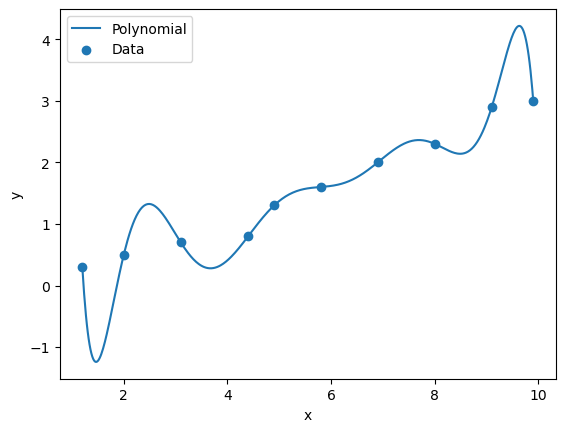

In [36]:
import numpy as np
from numpy import linalg as la
from matplotlib.pyplot import subplots, figure, show

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
A = np.zeros((len(x), len(x)))
for i in range(len(x)):
    for j in range(len(x)):
        A[i, j] = x[i]**j
coeff = la.solve(A, y)
print(f"coefficients = {coeff}")

def p(coefficients, xvalues):
    total = 0
    for i in range(len(coefficients)):
        total += coefficients[i] * xvalues**i
    return total

xplot = np.linspace(min(x), max(x), 500)
yplot = []
for i in xplot:
    yplot.append(p(coeff, i))

fig, ax = subplots()

ax.plot(xplot, yplot, label = "Polynomial")
ax.scatter(x, y, label = "Data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

fig.show()

**Question 7.6 : Cubic splines and OOP**

Linear interpolate at x = 5 = 1.3333333333333333
Polynomial interpolate at x = 5 = 1.373130157861283
Spline interpolate at x = 5 = 1.3744762382675277


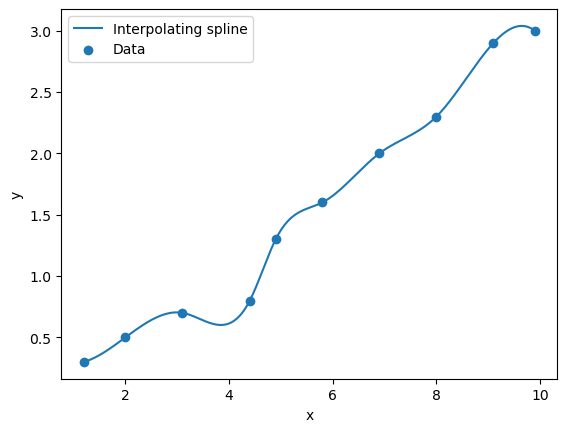

In [103]:
from scipy import interpolate as ip
from matplotlib.pyplot import subplots, figure, show

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

xplot = np.linspace(min(x), max(x), 500)
f = ip.interp1d(x, y, kind='cubic')
yplot = f(xplot)

fig, ax = subplots()

ax.plot(xplot, yplot, label = "Interpolating spline")
ax.scatter(x, y, label = "Data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

fig.show()

class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def linear(self):
        f = ip.interp1d(self.x, self.y, kind='linear')
        return f
        
    def polynomial(self):
        A = np.zeros((len(self.x), len(self.x)))
        for i in range(len(self.x)):
            for j in range(len(self.x)):
                A[i, j] = self.x[i]**j
        coeff = la.solve(A, self.y)
        
        def p(xvalues):
            total = 0
            for i in range(len(coeff)):
                total += coeff[i] * xvalues**i
            return total
        return p

    def spline(self):
        f = ip.interp1d(self.x, self.y, kind='cubic')
        return f
    
    def evaluate(self, xvalue, method='linear'):
        if method == 'linear':
            f = self.linear()
        elif method == 'polynomial':
            f = self.polynomial()
        elif method == 'spline':
            f = self.spline()
        else:
            print("Invalid method")
            return None
    
        return f(xvalue)
       
inter = interpolation(x, y)
print(f"Linear interpolate at x = 5 = {inter.evaluate(5.0, method='linear')}")
print(f"Polynomial interpolate at x = 5 = {inter.evaluate(5.0, method='polynomial')}")
print(f"Spline interpolate at x = 5 = {inter.evaluate(5.0, method='spline')}")

Interpolating spline is a better chocie because it has less oscillations and is more stable than the polynomial.

**Question 7.7 : Bilinear interpolation**

In [74]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
col = 0.2
row = 0.7
print(f"Interpolated intensity = {bilinearIP(I, col, row)}")

Interpolated intensity = 2.658


**Question 7.10 : Fitting the Lemaitre-Hubble relation**

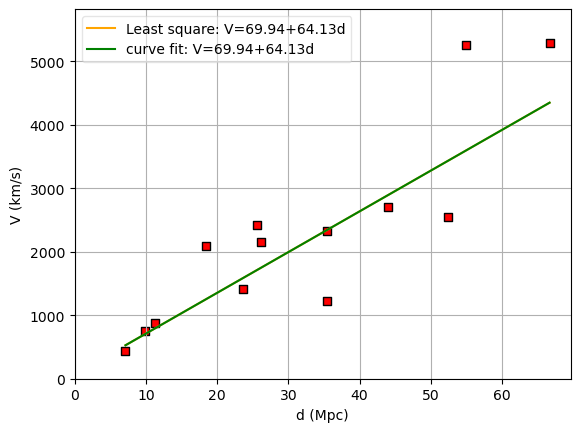

In [102]:
import numpy as np
from matplotlib.pyplot import figure, subplots, show
from scipy.optimize import leastsq, curve_fit

data = np.array([
   18.49, 2094.75, 0.3, 100,
   35.48, 2320.87, 2.2, 120,
   35.48, 1224.9,  3.0, 80,
   11.34, 872.13,  1.2, 80,
   7.12,  432.2,   0.4, 70,
   9.82,  751.0,   0.3, 75,
   23.66, 1410.0,  2.3, 70,
   44.0,  2700.0,  4.0, 110,
   66.7,  5292.0,  5.3, 120,
   52.4,  2550.0,  5.2, 100,
   55.0,  5253.0,  6.1, 150,
   25.6,  2419.0,  3.2, 110,
   26.19, 2158.0,  2.8, 110
])

d = data[0::4]
V = data[1::4]
sigd = data[2::4]
sigV = data[3::4]

# Least square fitting

def model(beta, d):
    beta0, beta1 = beta
    return beta0 + beta1*d

def residuals(beta, d, V, sigV):
    return (V - model(beta,d))/sigV

beta_start = [0, 70.0]
data = (d, V, sigV)
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result

if not pcov is None:
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())    
    dof = len(fvec) - len(beta)
    sderr = perror * np.sqrt(chi2/dof)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(d, V, marker='s', ec='k', color='r')
dmin = d.min(); dmax = d.max()
Vmin = model(beta,dmin); Vmax = model(beta,dmax)
label1 = f"Least square: V={beta[0]:.2f}+{beta[1]:.2f}d"
frame.plot([dmin, dmax], [Vmin, Vmax], label=label1, color='orange')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*V.max())

# Curve fitting

def model2(d, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*d

beta, pcov = curve_fit(model2, d, V, sigma=sigV, absolute_sigma=True)

X = np.array([d.min(),d.max()])
Y = model2(X, beta[0], beta[1])

label2 = f"curve fit: V={beta[0]:.2f}+{beta[1]:.2f}d"
frame.set_xlabel('d (Mpc)')
frame.set_ylabel('V (km/s)')
frame.plot(X, Y, label=label2, color='green')
frame.legend(fancybox=True, framealpha=0.5)
frame.grid()
show()